In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [2]:
#  1. STATE
class State(TypedDict):
    age: int

In [3]:
# 2. NODES

def check_age(state: State):
    print(f"Checking age: {state['age']}")
    return state


def adult(state: State):
    print("You are an adult.")
    return state


def minor(state: State):
    print("You are a minor.")
    return state

In [4]:
#  3. DECISION / ROUTING FUNCTION

def decide(state: State):

    if state["age"] >= 18:
        return "adult"

    return "minor"

In [5]:
# 4. CREATE GRAPH
builder = StateGraph(State)

In [6]:
#  ADD NODES
builder.add_node("check_age", check_age)
builder.add_node("adult", adult)
builder.add_node("minor", minor)


In [7]:
#  6. START → CHECK AGE

builder.add_edge(START, "check_age")


In [8]:
# 7. CONDITIONAL WORKFLOW

builder.add_conditional_edges(
    "check_age",
    decide,
    {
        "adult": "adult",
        "minor": "minor",
    }
)

In [9]:
#  8. NODES → END
builder.add_edge("adult", END)
builder.add_edge("minor", END)

In [10]:
# 9. COMPILE GRAPH
graph = builder.compile()

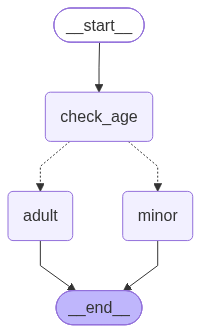

In [11]:
graph

In [12]:
#  10. RUN GRAPH
result = graph.invoke({
    "age": 20
})

Checking age: 20
You are an adult.


In [13]:
#  11. PRINT RESULT
print("\nFinal State:")
print(result)


Final State:
{'age': 20}
